Phần	Mục tiêu	Kết quả nhìn thấy
3️⃣	Tổng tồn kho theo sản phẩm	Xác định dòng hàng nào chiếm nhiều tồn kho
4️⃣	Theo màu sắc	Tìm màu bán chậm hoặc thừa
5️⃣	Theo size	Tìm size phổ biến/thiếu hàng
6️⃣	Heatmap size + color	Phát hiện chéo điểm dư thừa
7️⃣	So sánh trong từng Design	Tối ưu màu sản xuất
8️⃣	Category overview	Đánh giá hiệu quả từng phân khúc
9️⃣	Mean stock by size	Tìm pattern tồn kho cố định
🔟	Summary	Gợi ý hành động chiến lược cho BA/PM

In [5]:
# ===========================================
# 2️⃣ Làm sạch dữ liệu (bản fix lỗi)
# ===========================================
df.columns = df.columns.str.strip()

# Chuẩn hóa chuỗi
for col in ['SKU Code', 'Design No.', 'Category', 'Size', 'Color']:
    df[col] = df[col].astype(str).str.strip()

# --- Làm sạch cột Stock ---
# Loại bỏ khoảng trắng, ký tự lạ, giữ lại số
df['Stock'] = (
    df['Stock']
    .astype(str)
    .str.replace(r'[^0-9\-]', '', regex=True)  # chỉ giữ số và dấu '-'
    .replace('-', np.nan)                      # dấu '-' coi như thiếu dữ liệu
    .replace('', np.nan)                       # chuỗi trống cũng coi là thiếu
)

# Ép kiểu về số
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce')

# Điền giá trị thiếu bằng 0
df['Stock'] = df['Stock'].fillna(0)

print("✅ Dữ liệu sau khi làm sạch:")
print(df['Stock'].head(10))
print(df.info())


✅ Dữ liệu sau khi làm sạch:
0     5.0
1     5.0
2     3.0
3     6.0
4     3.0
5    11.0
6     3.0
7    16.0
8     8.0
9    14.0
Name: Stock, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9271 entries, 0 to 9270
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       9271 non-null   int64  
 1   SKU Code    9271 non-null   object 
 2   Design No.  9271 non-null   object 
 3   Stock       9271 non-null   float64
 4   Category    9271 non-null   object 
 5   Size        9271 non-null   object 
 6   Color       9271 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 507.1+ KB
None


📈 Ngưỡng tồn kho cao bất thường (95th percentile): 94.00
📉 Ngưỡng tồn kho thấp bất thường (5th percentile): 0.00

🔎 Top 10 SKU có tồn kho cao nhất:


,index,SKU Code,Design No.,Stock,Category,Size,Color
3948,3948,JNE3405-KR-XXL,JNE3405,1234.0,KURTA,XXL,Pink
3947,3947,JNE3405-KR-XS,JNE3405,1230.0,KURTA,XS,Pink
3300,3300,JNE1525-KR-UDF19BLACK-M,JNE1525,1082.0,KURTA,M,Black
3789,3789,JNE3368-KR-XXXL,JNE3368,985.0,KURTA,XXXL,Light Green
3495,3495,JNE2270-KR-487-XXL,JNE2270,949.0,KURTA,XXL,Beige
8301,8301,SET273-KR-NP-M,SET273,880.0,KURTA SET,M,Brown
3299,3299,JNE1525-KR-UDF19BLACK-L,JNE1525,874.0,KURTA,L,Black
8302,8302,SET273-KR-NP-S,SET273,871.0,KURTA SET,S,Brown
8304,8304,SET273-KR-NP-XS,SET273,862.0,KURTA SET,XS,Brown
3302,3302,JNE1525-KR-UDF19BLACK-XL,JNE1525,844.0,KURTA,XL,Black


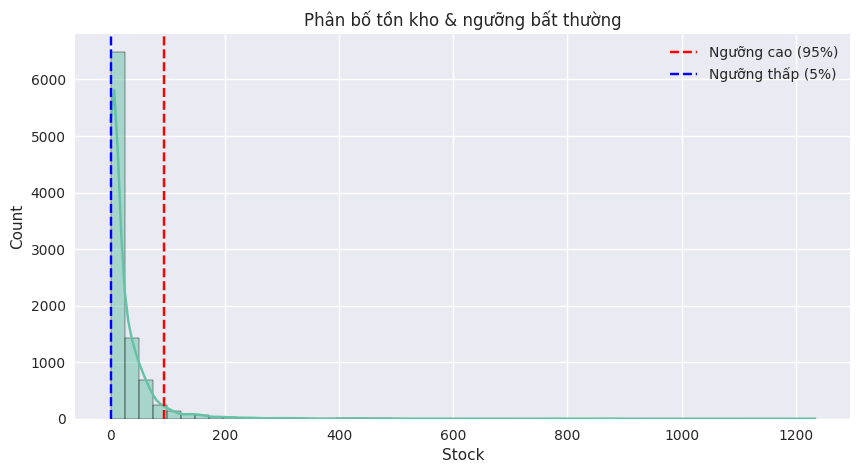

💬 [BA Insight]
- Các SKU vượt ngưỡng 95% → tồn kho cao bất thường, có thể đang ứ hàng hoặc forecast sai.
- SKU dưới ngưỡng 5% → có thể là hàng bán chạy, cần bổ sung sớm để tránh out-of-stock.
- Đề xuất: tạo báo cáo tự động gửi email hàng tuần cho các SKU này.



In [8]:
# ===========================================
# 11️⃣ Phân tích tồn kho bất thường (Outlier Analysis)
# ===========================================
import numpy as np

# Tính ngưỡng tồn kho cao bất thường (ví dụ: trên percentile 95%)
threshold_high = df['Stock'].quantile(0.95)
threshold_low = df['Stock'].quantile(0.05)

outliers_high = df[df['Stock'] > threshold_high]
outliers_low = df[df['Stock'] < threshold_low]

print(f"📈 Ngưỡng tồn kho cao bất thường (95th percentile): {threshold_high:.2f}")
print(f"📉 Ngưỡng tồn kho thấp bất thường (5th percentile): {threshold_low:.2f}\n")

print("🔎 Top 10 SKU có tồn kho cao nhất:")
display(outliers_high.sort_values(by='Stock', ascending=False).head(10))

# --- Biểu đồ trực quan hoá tồn kho phân bố ---
plt.figure(figsize=(10,5))
sns.histplot(df['Stock'], bins=50, kde=True)
plt.axvline(threshold_high, color='red', linestyle='--', label='Ngưỡng cao (95%)')
plt.axvline(threshold_low, color='blue', linestyle='--', label='Ngưỡng thấp (5%)')
plt.title("Phân bố tồn kho & ngưỡng bất thường")
plt.legend()
plt.show()

print("💬 [BA Insight]")
print("- Các SKU vượt ngưỡng 95% → tồn kho cao bất thường, có thể đang ứ hàng hoặc forecast sai.")
print("- SKU dưới ngưỡng 5% → có thể là hàng bán chạy, cần bổ sung sớm để tránh out-of-stock.")
print("- Đề xuất: tạo báo cáo tự động gửi email hàng tuần cho các SKU này.\n")


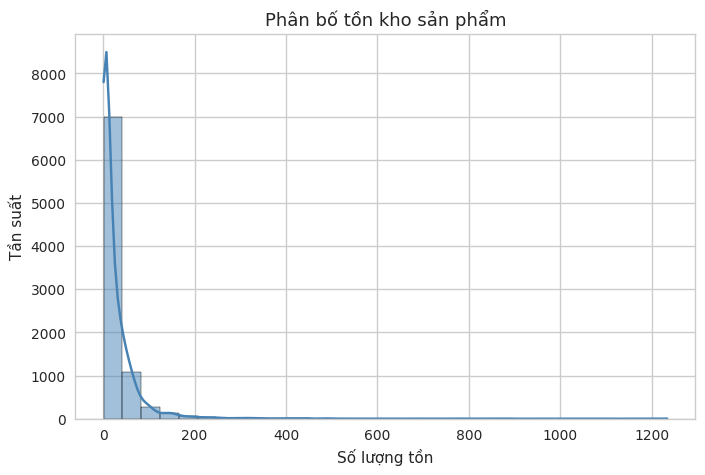

💬 [BA Insight] Nếu đồ thị lệch phải (nhiều sản phẩm tồn ít, vài sản phẩm tồn cực cao) ⇒ cần kiểm tra các design outlier để tránh đọng vốn.


/tmp/ipython-input-2805525046.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_designs.values, y=top_designs.index, palette='viridis')


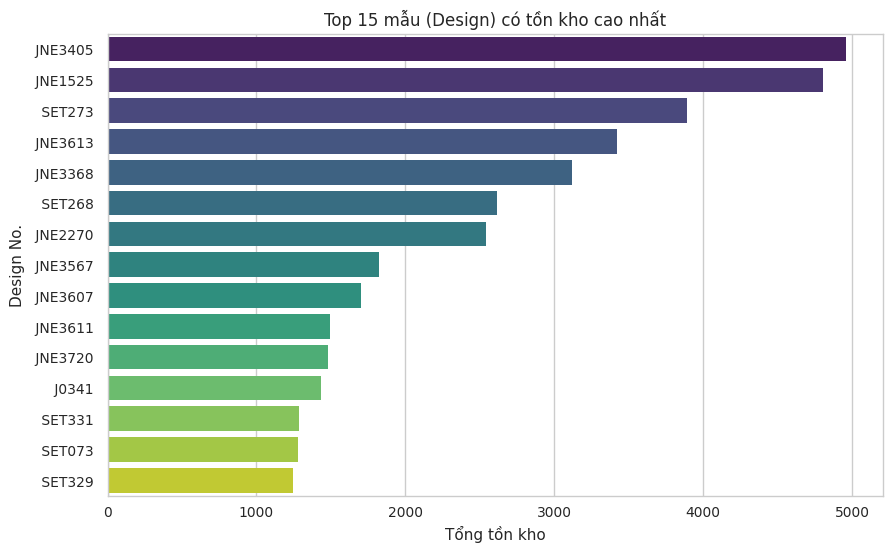

💬 [BA Insight] Các mẫu top tồn có thể bị chậm bán hoặc sản xuất vượt kế hoạch. Đề xuất: chạy khuyến mãi hoặc giảm nhập các mẫu này.


/tmp/ipython-input-2805525046.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Stock', data=df, palette='Set2')


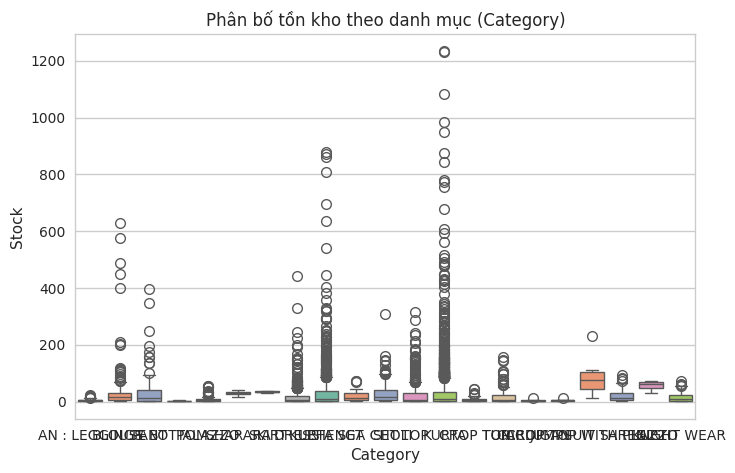

💬 [BA Insight] Nếu một Category có tồn trung vị cao bất thường, có thể sản phẩm trong nhóm đó đang bị dư thừa. Cần xem lại dự báo nhu cầu nhóm này.


/tmp/ipython-input-2805525046.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_size.index, y=avg_size.values, palette='coolwarm')


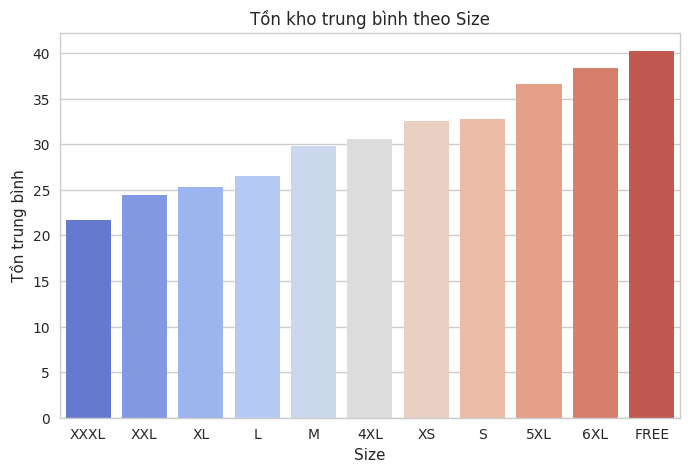

/tmp/ipython-input-2805525046.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_color.values, y=avg_color.index, palette='mako')


💬 [BA Insight] Nếu Size lớn (L, XL) tồn cao hơn hẳn => dự báo sai cơ cấu khách hàng. Nên điều chỉnh tỉ lệ sản xuất theo dữ liệu bán thực tế.


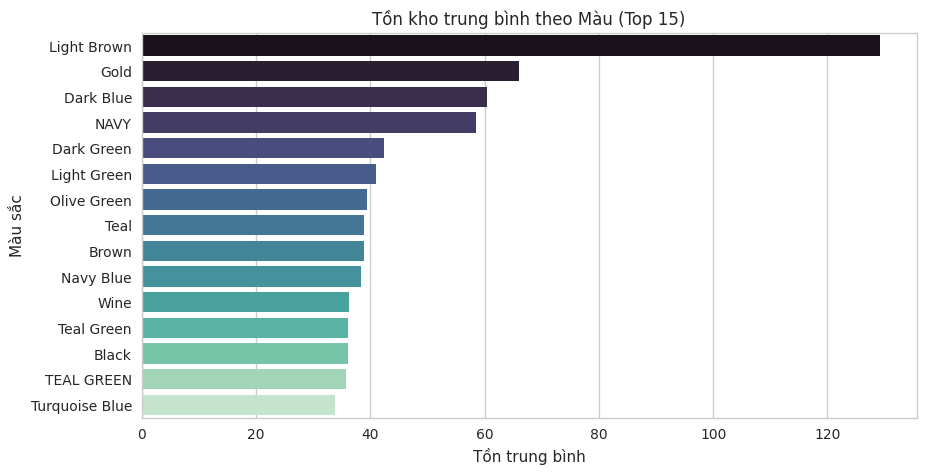

💬 [BA Insight] Màu nào tồn cao nhưng bán chậm (nếu có dữ liệu bán) => thị hiếu khách thay đổi. Có thể chạy khuyến mãi hoặc ngừng nhập.


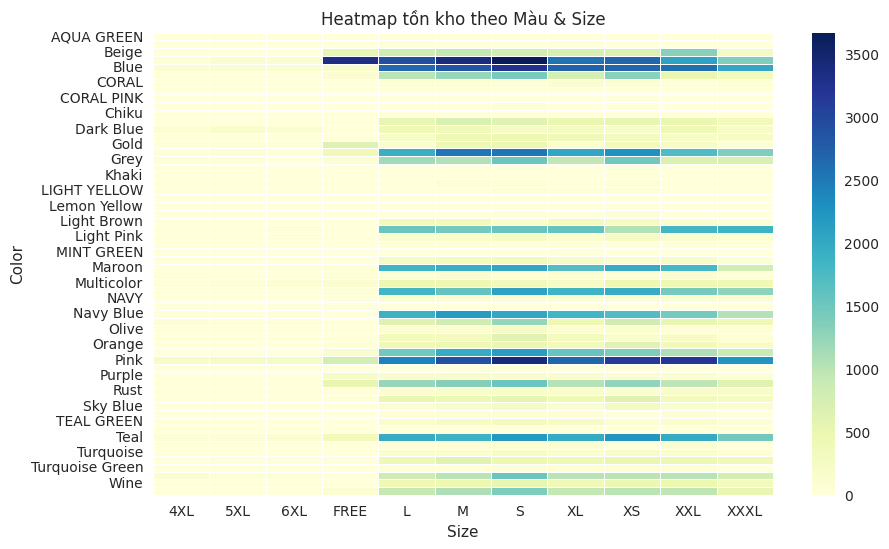

💬 [BA Insight] Dễ phát hiện Size nào đang tồn nhiều trong từng màu. Ví dụ: Màu Đen Size L tồn cao => có thể do nhập dư theo xu hướng cũ.


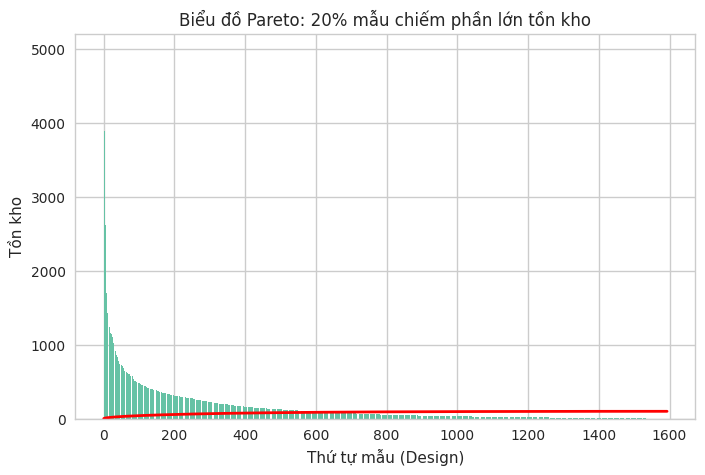

💬 [BA Insight] Nếu đường đỏ đạt 80% khi mới ~20% mẫu ⇒ tồn kho tập trung vào ít sản phẩm ⇒ cần quản lý riêng nhóm này (A-class).


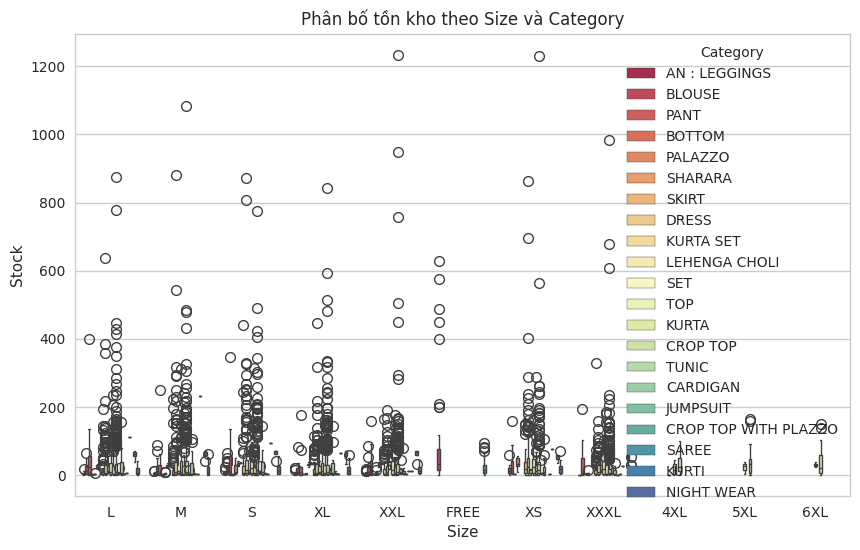

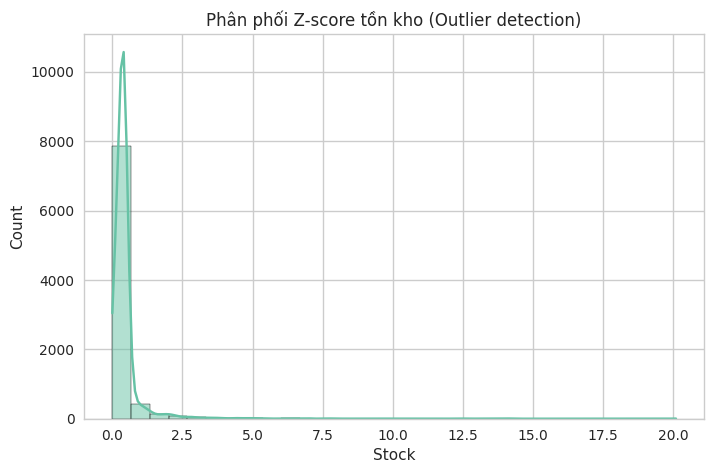

💬 [BA Insight] Có 115 sản phẩm bị coi là outlier (tồn bất thường cao/thấp). Cần review thủ công.


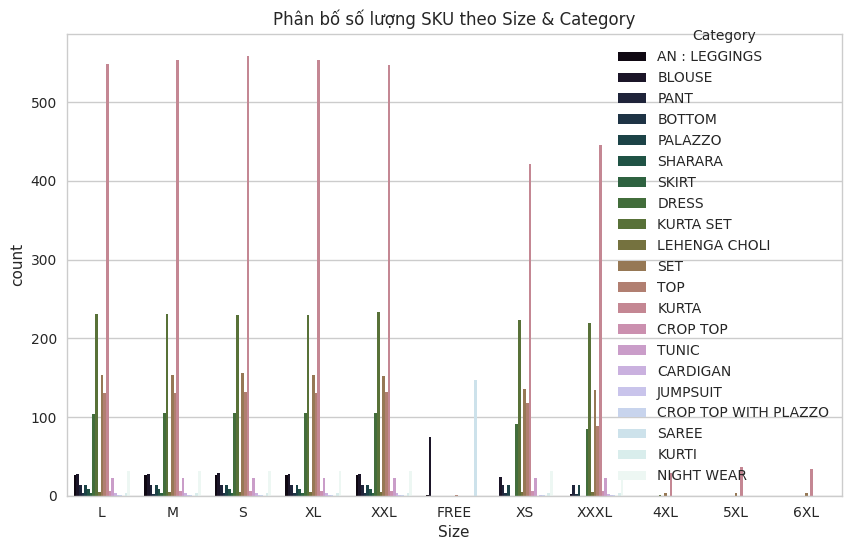

💬 [BA Insight] Nếu Size nào chiếm áp đảo nhưng tồn nhiều => sai cơ cấu nhập hàng.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.unicode_minus'] = False

# Giả sử df là DataFrame sau khi làm sạch
# df['Stock'] = df['Stock'].astype(float)

# 1️⃣ Phân bố tổng thể tồn kho
plt.figure(figsize=(8,5))
sns.histplot(df['Stock'], bins=30, kde=True, color='steelblue')
plt.title("Phân bố tồn kho sản phẩm", fontsize=13)
plt.xlabel("Số lượng tồn")
plt.ylabel("Tần suất")
plt.show()

print("💬 [BA Insight] Nếu đồ thị lệch phải (nhiều sản phẩm tồn ít, vài sản phẩm tồn cực cao) ⇒ cần kiểm tra các design outlier để tránh đọng vốn.")


# 2️⃣ Top 15 mẫu có tồn kho cao nhất
plt.figure(figsize=(10,6))
top_designs = df.groupby('Design No.')['Stock'].sum().nlargest(15)
sns.barplot(x=top_designs.values, y=top_designs.index, palette='viridis')
plt.title("Top 15 mẫu (Design) có tồn kho cao nhất")
plt.xlabel("Tổng tồn kho")
plt.ylabel("Design No.")
plt.show()

print("💬 [BA Insight] Các mẫu top tồn có thể bị chậm bán hoặc sản xuất vượt kế hoạch. Đề xuất: chạy khuyến mãi hoặc giảm nhập các mẫu này.")


# 3️⃣ Tồn kho theo Category
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Stock', data=df, palette='Set2')
plt.title("Phân bố tồn kho theo danh mục (Category)")
plt.show()

print("💬 [BA Insight] Nếu một Category có tồn trung vị cao bất thường, có thể sản phẩm trong nhóm đó đang bị dư thừa. Cần xem lại dự báo nhu cầu nhóm này.")


# 4️⃣ Tồn kho trung bình theo Size
plt.figure(figsize=(8,5))
avg_size = df.groupby('Size')['Stock'].mean().sort_values()
sns.barplot(x=avg_size.index, y=avg_size.values, palette='coolwarm')
plt.title("Tồn kho trung bình theo Size")
plt.xlabel("Size")
plt.ylabel("Tồn trung bình")
plt.show()

print("💬 [BA Insight] Nếu Size lớn (L, XL) tồn cao hơn hẳn => dự báo sai cơ cấu khách hàng. Nên điều chỉnh tỉ lệ sản xuất theo dữ liệu bán thực tế.")


# 5️⃣ Tồn kho trung bình theo Màu sắc
plt.figure(figsize=(10,5))
avg_color = df.groupby('Color')['Stock'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=avg_color.values, y=avg_color.index, palette='mako')
plt.title("Tồn kho trung bình theo Màu (Top 15)")
plt.xlabel("Tồn trung bình")
plt.ylabel("Màu sắc")
plt.show()

print("💬 [BA Insight] Màu nào tồn cao nhưng bán chậm (nếu có dữ liệu bán) => thị hiếu khách thay đổi. Có thể chạy khuyến mãi hoặc ngừng nhập.")


# 6️⃣ Heatmap Màu vs Size
pivot = df.pivot_table(values='Stock', index='Color', columns='Size', aggfunc='sum', fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5)
plt.title("Heatmap tồn kho theo Màu & Size")
plt.show()

print("💬 [BA Insight] Dễ phát hiện Size nào đang tồn nhiều trong từng màu. Ví dụ: Màu Đen Size L tồn cao => có thể do nhập dư theo xu hướng cũ.")


# 7️⃣ Biểu đồ Pareto (20% Design chiếm bao nhiêu % tồn)
plt.figure(figsize=(8,5))
design_stock = df.groupby('Design No.')['Stock'].sum().sort_values(ascending=False)
cum_perc = design_stock.cumsum()/design_stock.sum()*100
plt.bar(range(len(design_stock)), design_stock)
plt.plot(cum_perc.values, color='red', linewidth=2)
plt.title("Biểu đồ Pareto: 20% mẫu chiếm phần lớn tồn kho")
plt.xlabel("Thứ tự mẫu (Design)")
plt.ylabel("Tồn kho")
plt.show()

print("💬 [BA Insight] Nếu đường đỏ đạt 80% khi mới ~20% mẫu ⇒ tồn kho tập trung vào ít sản phẩm ⇒ cần quản lý riêng nhóm này (A-class).")


# 8️⃣ Boxplot tổng hợp: tồn kho theo Category & Size
plt.figure(figsize=(10,6))
sns.boxplot(x='Size', y='Stock', hue='Category', data=df, palette='Spectral')
plt.title("Phân bố tồn kho theo Size và Category")
plt.show()


# 9️⃣ Kiểm tra outlier theo Z-score
z = np.abs((df['Stock'] - df['Stock'].mean()) / df['Stock'].std())
outliers = df[z > 3]
plt.figure(figsize=(8,5))
sns.histplot(z, bins=30, kde=True)
plt.title("Phân phối Z-score tồn kho (Outlier detection)")
plt.show()
print(f"💬 [BA Insight] Có {len(outliers)} sản phẩm bị coi là outlier (tồn bất thường cao/thấp). Cần review thủ công.")


# 🔟 Phân tích phân bố Size trong từng Category (count)
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Size', hue='Category', palette='cubehelix')
plt.title("Phân bố số lượng SKU theo Size & Category")
plt.show()

print("💬 [BA Insight] Nếu Size nào chiếm áp đảo nhưng tồn nhiều => sai cơ cấu nhập hàng.")


In [12]:
import numpy as np

# --- Làm sạch lại cột Stock triệt để ---
df['Stock'] = (
    df['Stock']
    .astype(str)
    .str.strip()                              # xoá khoảng trắng đầu cuối
    .replace('-', np.nan)                     # thay dấu '-' bằng NaN
    .str.replace(r'[^0-9.\-]', '', regex=True) # loại ký tự không phải số
    .replace('', np.nan)                      # chuỗi rỗng → NaN
    .astype(float)                            # ép về float
)

print("✅ Kiểm tra lại dữ liệu cột Stock:")
print(df['Stock'].head(10))
print(df['Stock'].dtype)


✅ Kiểm tra lại dữ liệu cột Stock:
0     5.0
1     5.0
2     3.0
3     6.0
4     3.0
5    11.0
6     3.0
7    16.0
8     8.0
9    14.0
Name: Stock, dtype: float64
float64


1) Mục tiêu bài toán (what to deliver)

Thực hiện profiling (tính toán + trực quan) cho dataset SKU.

Tìm những phân đoạn (segments) sản phẩm bằng ML (clustering).

Viết báo cáo 3 trang A4 (PDF) trình bày key findings + recommendations (chiến lược tồn kho, marketing, sản xuất).

Nộp working file (Excel / PowerBI / .ipynb) có bước phân tích, notes, charts.

Thời gian làm: bạn đã ghi 2:00 PM — 4:00 PM (120 phút). Tổng hợp và xuất 3 trang A4 — chú ý không quá 3 trang.

2) Quy trình phân tích (step-by-step — theo thứ tự thực hiện trong Colab / Jupyter)
A. Data cleaning & profiling (15–25 phút)

Mục tiêu: đảm bảo Stock numeric, không NA/garbled; chuẩn hóa Design No., Color, Size, Category, tách SKU Code thành Design/Color/Size nếu cần.

In [14]:
import pandas as pd, numpy as np
df = pd.read_csv("RBAC_Data_Round1.csv")
# strip columns
df.columns = df.columns.str.strip()
for c in ['SKU Code','Design No.','Category','Size','Color']:
    df[c] = df[c].astype(str).str.strip()
# Clean Stock robustly:
df['Stock'] = (df['Stock'].astype(str).str.strip()
               .replace('-', np.nan)
               .str.replace(r'[^0-9.\-]', '', regex=True)
               .replace('', np.nan))
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce').fillna(0)
# Optionally split SKU Code
sku_split = df['SKU Code'].str.replace(' ','').str.split('-', expand=True)
if sku_split.shape[1] >= 3:
    df['SKU_Design'] = sku_split[0]
    df['SKU_Color'] = sku_split[1]
    df['SKU_Size']  = sku_split[2]


B. EDA — visualizations (30–40 phút)

Các biểu đồ cần có (tối thiểu cho 3-page PDF + working file):

Histogram phân bố Stock (kèm KDE) — phát hiện skew/outliers.

Top 10 Design No. theo tổng tồn kho (horizontal bar).

Tổng tồn kho theo Color (bar).

Heatmap Color × Size (pivot sum) — tìm tổ hợp tồn cao.

Boxplot Stock theo Size — biến động kích cỡ.

Pareto (cumulative) cho Design: % SKU chiếm 80% tồn.

Outlier detection visualization (Z-score histogram + table of top outliers).

Donut chart % tồn kho theo Category (trang báo cáo đẹp).

<Axes: ylabel='Design No.'>

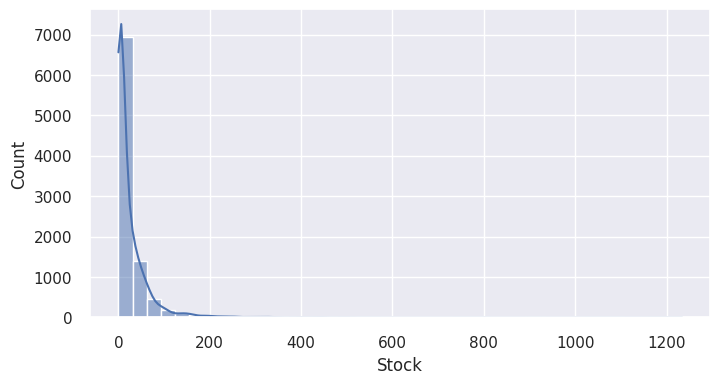

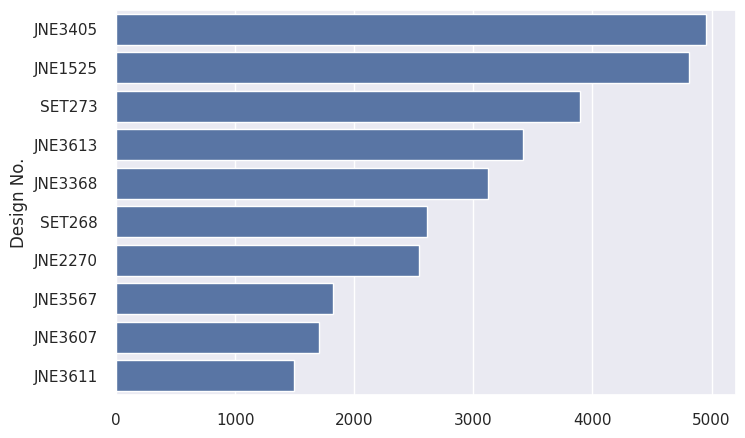

In [18]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set()
# histogram
plt.figure(figsize=(8,4)); sns.histplot(df['Stock'], bins=40, kde=True)
# top designs
top = df.groupby('Design No.')['Stock'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5)); sns.barplot(x=top.values, y=top.index)
# heatmap
# pivot = df.pivot_table(values='Stock', index='Color', columns='Size', aggfunc='sum', fill_value=0)
# plt.figure(figsize=(10,6)); sns.heatmap(pivot, annot=True, fmt='.0f')
